# The fine RK6 reference (Block C, C1)

This notebook **computes nothing**. It loads what `check_tableau.py`,
`measure_convergence.py` and `plot.py` wrote and displays it. Every number
below is read from `results/`; the argument that goes with them is in
[README.md](README.md).


In [1]:
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
           "NUMEXPR_NUM_THREADS"):
    os.environ[_v] = "1"
os.environ["PYTHONNOUSERSITE"] = "1"
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
RESULTS, FIGURES = "results", "figures"


## C1.1 The tableau battery

Five checks: that the coefficients are the ones in the van der Pol study's
`rk6.py`, that they satisfy the tableau identities, that they reproduce order
six on three problems with exact solutions, that `rk6_rows` **itself** shows
order six on the LHCb equation of motion with a smooth field, and that its
mechanics (shortened last step, backward legs, masking, q/p passthrough) are
right.

In [2]:
checks = json.load(open(os.path.join(RESULTS, "tableau_checks.json")))
print("all pass:", checks["all_pass"], " on", checks["node"], " in", checks["wall_s"], "s")
for name, c in checks["checks"].items():
    print("%-42s %s" % (name, "ok" if c["passes"] else "FAIL"))


all pass: True  on stbc-i2.nikhef.nl  in 71.68 s
1_provenance                               ok
2_identities                               ok
3_order_on_exact_solution_problems         ok
4_order_of_rk6_rows_on_a_smooth_field      ok
5_mechanics                                ok


In [3]:
p = checks["checks"]["3_order_on_exact_solution_problems"]["problems"]
pd.DataFrame([{"problem": k, "fitted order": v["fitted_order"],
               "points above roundoff": v["points_above_roundoff"]}
              for k, v in p.items()])


,problem,fitted order,points above roundoff
0,linear: dy/dt = -y,6.057206,5
1,nonlinear: dy/dt = -y^2,6.266629,6
2,non-autonomous: dy/dt = y cos t,5.748400,6


In [4]:
c4 = checks["checks"]["4_order_of_rk6_rows_on_a_smooth_field"]
pd.DataFrame({"step [mm]": c4["step_sizes_mm"],
              "max |error| [mm]": c4["max_abs_error_mm"]}).assign(
    fitted_order=c4["fitted_order"])


,step [mm],max |error| [mm],fitted_order
0,640.0,1.662444e-05,6.233914
1,320.0,2.122019e-07,6.233914
2,160.0,2.934655e-09,6.233914
3,80.0,4.200729e-11,6.233914


In [5]:
pd.Series(checks["checks"]["5_mechanics"])

span_not_a_whole_number_of_steps_mm                                                 5177.8
forward_then_back_closure_mm                                                           0.0
backward_leg_runs                                                                     True
batch_vs_one_at_a_time_max_abs_diff                                                    0.0
batch_legs                               [[2648.2, 2648.2, 3000.0, 7826.0, 5000.0], [78...
leg_shorter_than_one_step_finite                                                      True
zero_length_leg_returns_start_exactly                                                 True
qop_passthrough_exact                                                                 True
passes                                                                                True
dtype: object

## C1.2 Convergence on 200 cross-magnet legs

In [6]:
meta = json.load(open(os.path.join(RESULTS, "reference_convergence_meta.json")))
S = pd.read_csv(os.path.join(RESULTS, "reference_convergence.csv"))
print("legs:", meta["legs"]["n"], " span", round(meta["legs"]["span_mm"]["median"]), "mm median")
print("field:", meta["field"]["which"], meta["field"]["md5"])
S.head()


legs: 200  span 5174 mm median
field: up 9e49ddc4313b589f273540e7e0bb513b


,measurement,step_mm,reference_step_mm,integrator,field,group_kind,group,n,pos_med_um,pos_p95_um,pos_max_um,slope_med_urad,slope_p95_urad,slope_max_urad
0,step halving,0.8,0.4,RK6,v8r1.up,all,all,200,0.000094,0.000641,0.001128,0.000039,0.000286,0.000450
1,step halving,0.8,0.4,RK6,v8r1.up,p_band,1-2 GeV,40,0.000425,0.000998,0.001084,0.000175,0.000401,0.000450
2,step halving,0.8,0.4,RK6,v8r1.up,p_band,2-5 GeV,40,0.000209,0.000588,0.001128,0.000083,0.000243,0.000377
3,step halving,0.8,0.4,RK6,v8r1.up,p_band,5-10 GeV,40,0.000096,0.000287,0.000306,0.000039,0.000098,0.000129
4,step halving,0.8,0.4,RK6,v8r1.up,p_band,10-25 GeV,40,0.000052,0.000090,0.000095,0.000020,0.000039,0.000041


In [7]:
lad = S[(S.measurement == "step halving") & (S.group == "all")]
lad.pivot_table(index="step_mm", columns="field",
                values=["pos_med_um", "pos_p95_um"]).sort_index(ascending=False)


pos_med_um                          pos_p95_um                    
field   smooth analytic v8r1.down   v8r1.up smooth analytic v8r1.down   v8r1.up
step_mm                                                                        
0.8        9.912355e-07       NaN  0.000094        0.000005       NaN  0.000641
0.4                 NaN       NaN  0.000012             NaN       NaN  0.000151
0.2        3.969461e-06       NaN  0.000008        0.000022       NaN  0.000050
0.1                 NaN  0.000003  0.000002             NaN  0.000685  0.000016

In [8]:
print("successive halving ratios (64 = clean order 6):",
      meta["successive_halving_ratios"])
print("closure at 0.1 mm, median um:", meta["closure_median_um"])
print("RK4 against the fine reference, median um:", meta["rk4_vs_rk6_median_um"])
print("other polarity cross-check:", meta["cross_check_other_polarity"])


successive halving ratios (64 = clean order 6): [8.02, 1.504, 3.762]
closure at 0.1 mm, median um: 3.6571226047499295e-06
RK4 against the fine reference, median um: {'5.0': 0.012694930724421738, '1.0': 0.0008174113403924821}
other polarity cross-check: {'field': 'v8r1.down', 'step_halving_0.1_vs_0.05_median_um': 2.8038300570187857e-06, 'closure_median_um': 3.6413574378002522e-06, 'why': "the map's grid, not its sign, sets the floor; these legs were chosen on the up map so this is the same 200 start states integrated through the other polarity"}


In [9]:
S[(S.measurement == "step halving") & (S.group_kind == "p_band")
  & (S.field == "v8r1." + meta["field"]["which"])].pivot_table(
      index="group", columns="step_mm", values="pos_med_um")


step_mm,0.1,0.2,0.4,0.8
group,,,,
1-2 GeV,1.390378e-05,0.000045,0.000061,0.000425
10-25 GeV,1.340155e-06,0.000005,0.000008,0.000052
2-5 GeV,5.593620e-06,0.000021,0.000027,0.000209
25-200 GeV,5.894840e-07,0.000002,0.000003,0.000022
5-10 GeV,2.615266e-06,0.000010,0.000014,0.000096


## C1.3 Cost

In [10]:
print(json.dumps(meta["cost"], indent=1))

{
 "wall_s": {
  "rk6_0.8_mm_wall_s": 36.06,
  "rk6_0.4_mm_wall_s": 62.5,
  "rk6_0.2_mm_wall_s": 109.56,
  "rk6_0.1_mm_wall_s": 208.65,
  "rk6_0.05_mm_wall_s": 422.52,
  "closure_wall_s": 210.13,
  "rk4_5_mm_wall_s": 2.33,
  "rk4_1_mm_wall_s": 11.63
 },
 "seconds_per_track_at_0.1_mm": 1.0433,
 "crossing_mm": 5174.269775390625,
 "batch": {
  "200": {
   "wall_s_for_20mm": 0.675,
   "extrapolated_s_per_track_for_the_crossing": 0.8727
  },
  "1000": {
   "wall_s_for_20mm": 1.007,
   "extrapolated_s_per_track_for_the_crossing": 0.2604
  },
  "5000": {
   "wall_s_for_20mm": 2.587,
   "extrapolated_s_per_track_for_the_crossing": 0.1339
  },
  "20000": {
   "wall_s_for_20mm": 9.276,
   "extrapolated_s_per_track_for_the_crossing": 0.12
  }
 },
 "peak_rss_MB": 145.5,
 "note": "one thread; the field call is the whole cost, and it amortises over the batch, so the per-track figure falls until the batch stops fitting in cache"
}


## The figure

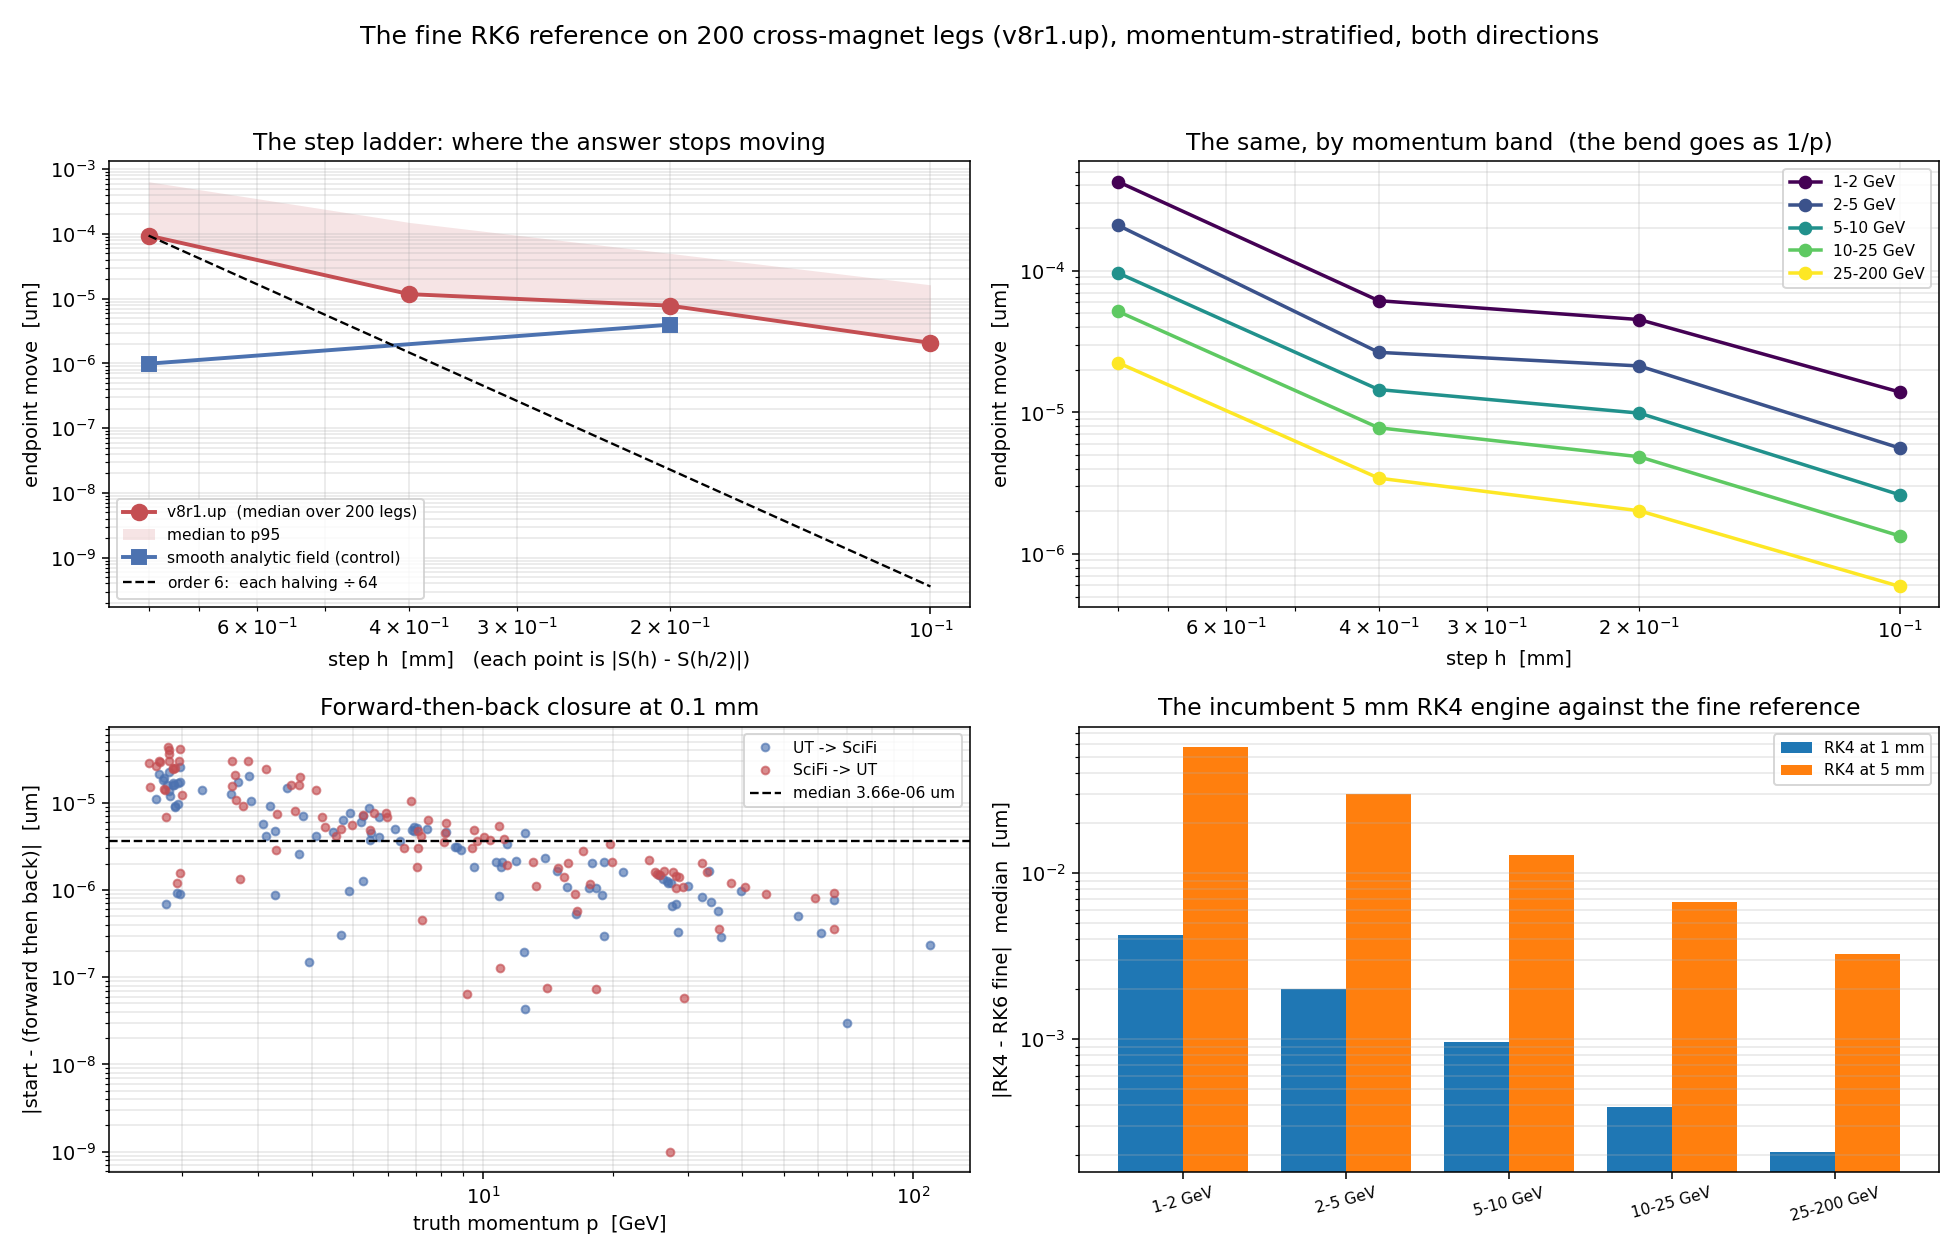

In [11]:
display(Image(filename=os.path.join(FIGURES, "reference_convergence.png")))